Marker-gene heatmaps of the single-cell experiments.

Each figure shows the z-scored expression of the top cluster markers (genes x cells).  Clusters are named by their biological identity on the bar above the heatmap.  Gene rows are sectioned by the cluster they mark -- the colour strip on the y axis codes that cluster, using the same colours -- so a curated gene group whose genes mark more than one cluster is drawn as one labelled block per section.

Plotting code lives in `scripts/heatmap_functions.py`.

## Heatmap of the SHX experiment

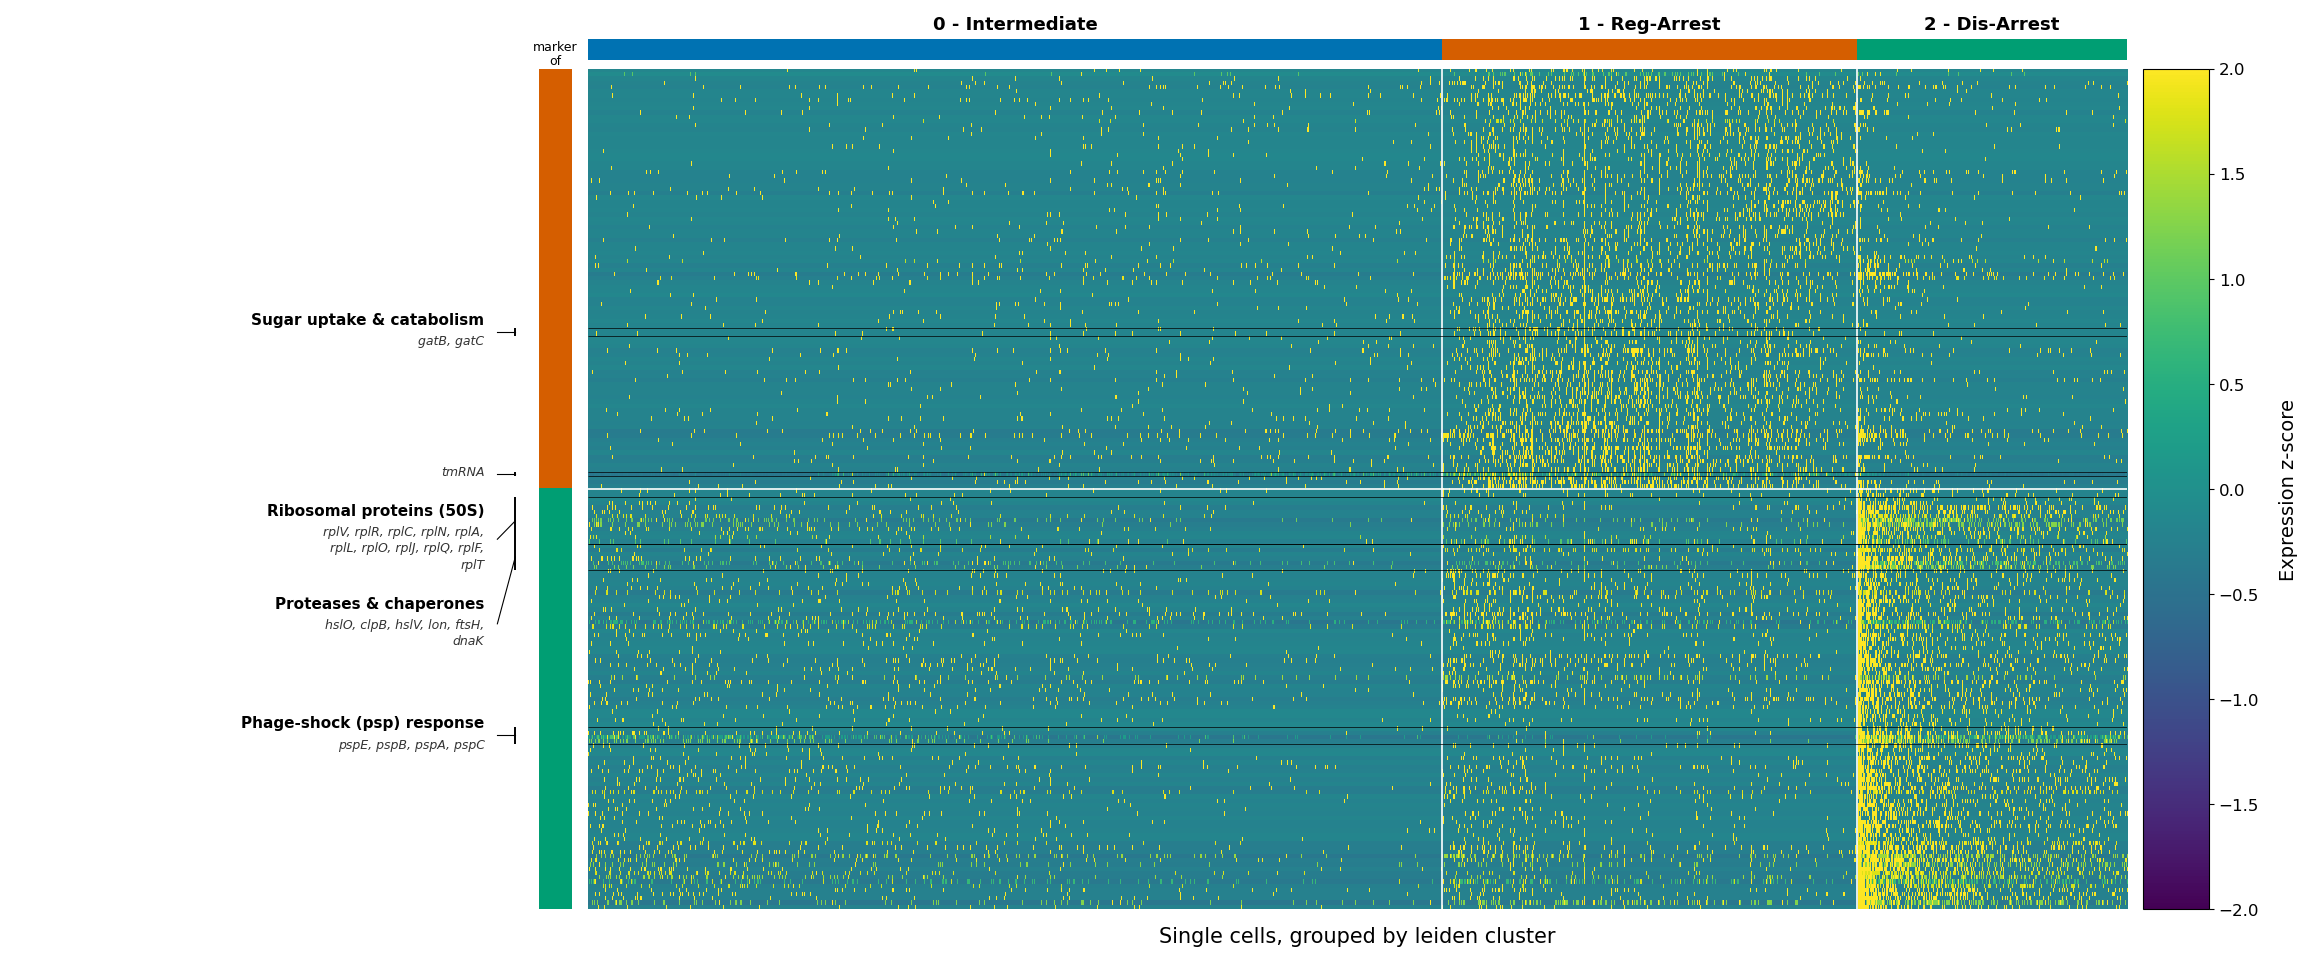

In [1]:
import os, sys

import scanpy as sc
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())            # scripts/ -- where heatmap_functions.py lives
from heatmap_functions import plot_marker_heatmap

# ---------------- CONFIG ----------------
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")

cats     = ["0", "1", "2"]              # leiden clusters, left-to-right on the x axis
topN     = 100                          # per cluster, upregulated genes only
p_cut    = 0.05
layer    = "counts"

# Biological identity of each leiden cluster -> shown on the bar above the
# heatmap and as the colour code of the strip on the y axis.
cluster_labels = {
    "0": "Intermediate",
    "1": "Reg-Arrest",
    "2": "Dis-Arrest",
}

# Curated groups to emphasise.  Keys are the labels printed on the y axis.
gene_groups = {
    "Phage-shock (psp) response": ["pspA", "pspB", "pspC", "pspD", "pspE", "pspF", "pspG"],
    "Proteases & chaperones": ["clpA", "clpB", "clpX", "clpP", "lon", "ftsH",
                               "dnaK", "hslO", "hslU", "hslV"],
    "Ribosomal proteins (50S)": ["rplA", "rplB", "rplC", "rplD", "rplE", "rplF", "rplJ",
                                 "rplK", "rplL", "rplM", "rplN", "rplO", "rplP", "rplQ",
                                 "rplR", "rplS", "rplT", "rplU", "rplV"],
    "Sugar uptake & catabolism": ["gatA", "gatB", "gatC", "gatZ", "mglA", "araG", "araF"],
    "Trans-translation": ["tmRNA"],
}
# ---------------------------------------

adata_shx = sc.read_h5ad(os.path.join(
    DATA_DIR, "adata_shx_paper_barcodes_20260818_142615.h5ad"))

fig, shx_info = plot_marker_heatmap(
    adata_shx, cats, cluster_labels, gene_groups,
    outfile="heatmap_cells_by_genes_shx.pdf",
    topN=topN, p_cut=p_cut, layer=layer,
)
fig.savefig("heatmap_cells_by_genes_shx_preview.png", bbox_inches="tight", dpi=110)
plt.show()


## Heatmap of the VapC experiment

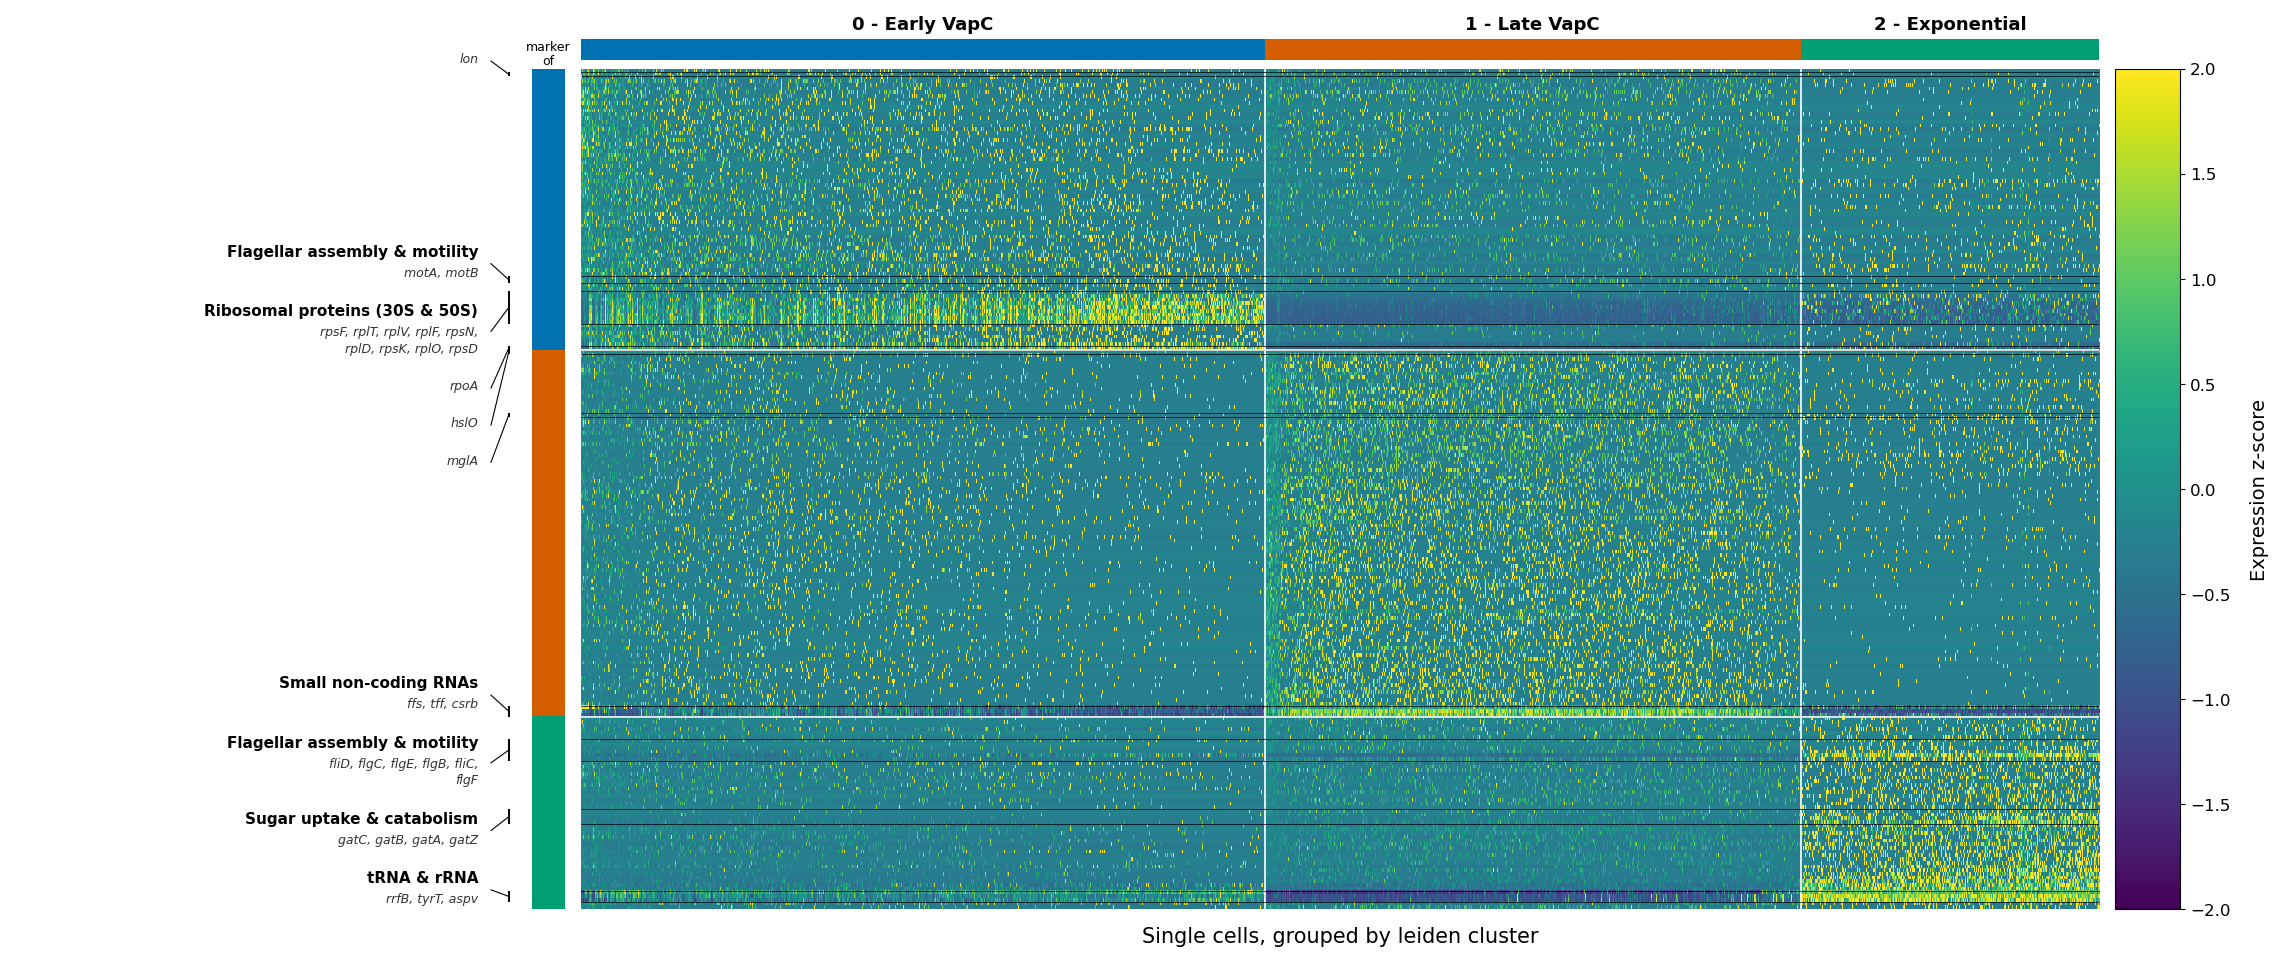

In [2]:
import os, sys

import scanpy as sc
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())            # scripts/ -- where heatmap_functions.py lives
from heatmap_functions import plot_marker_heatmap

# ---------------- CONFIG ----------------
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")

cats     = ["0", "1", "2"]              # leiden clusters, left-to-right on the x axis
topN     = 100                          # per cluster, upregulated genes only
p_cut    = 0.05
layer    = "counts"

cluster_labels = {
    "0": "Early VapC",
    "1": "Late VapC",
    "2": "Exponential",
}

gene_groups = {
    "Proteases & chaperones": ["clpA", "clpB", "clpX", "clpP", "lon", "ftsH",
                               "dnaK", "hslO", "hslU", "hslV"],
    "Ribosomal proteins (30S & 50S)": ["rplA", "rplC", "rplD", "rplE", "rplF", "rplJ",
                                       "rplL", "rplM", "rplN", "rplO", "rplQ", "rplR",
                                       "rplS", "rplT", "rplU", "rplV",
                                       "rpsA", "rpsC", "rpsD", "rpsE", "rpsF", "rpsH",
                                       "rpsI", "rpsJ", "rpsK", "rpsL", "rpsM", "rpsN",
                                       "rpsO"],
    "Sugar uptake & catabolism": ["gatA", "gatB", "gatC", "gatZ", "mglA", "araG", "araF"],
    "Flagellar assembly & motility": ["fliA", "fliB", "fliC", "fliD", "fliE", "fliF",
                                      "fliS", "fliT", "flgA", "flgB", "flgC", "flgM",
                                      "flgN", "flgE", "flgF", "flgK", "flgL",
                                      "motA", "motB"],
    "RNA polymerase": ["rpoA"],
    "tRNA & rRNA": ["tyrT", "aspv", "rrfB"],
    "Small non-coding RNAs": ["ffs", "tff", "csrb"],
}
# ---------------------------------------

adata_vapc = sc.read_h5ad(os.path.join(DATA_DIR, "scanpy_vapc.h5ad"))

fig, vapc_info = plot_marker_heatmap(
    adata_vapc, cats, cluster_labels, gene_groups,
    outfile="heatmap_cells_by_genes_vapc.pdf",
    topN=topN, p_cut=p_cut, layer=layer,
)
fig.savefig("heatmap_cells_by_genes_vapc_preview.png", bbox_inches="tight", dpi=110)
plt.show()


In [3]:
# Where each curated gene block ended up, and the cluster every gene marks
print(vapc_info["group_ranges"])
vapc_info["markers"][["names", "chosen_group", "scores", "pvals_adj"]].head()


[('Proteases & chaperones', 1, 2), ('Flagellar assembly & motility', 56, 58), ('Ribosomal proteins (30S & 50S)', 60, 69), ('RNA polymerase', 75, 76), ('Proteases & chaperones', 76, 77), ('Sugar uptake & catabolism', 93, 94), ('Small non-coding RNAs', 172, 175), ('Flagellar assembly & motility', 181, 187), ('Sugar uptake & catabolism', 200, 204), ('tRNA & rRNA', 222, 225)]


,names,chosen_group,scores,pvals_adj
0,rpsD,0,54.296600,0.0
1,rplO,0,53.873642,0.0
2,rpoA,0,52.698631,0.0
3,rpsK,0,52.432800,0.0
4,rplD,0,48.488537,0.0
